# Statistical Analysis

In [1]:
import pandas as pd
import numpy as np
import ast
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns


In [2]:
BG_COLOR = "#23272e"  
BOX_COLOR = "#61afef"  
TEXT_COLOR = "#abb2bf"  

plt.rcParams.update(
    {
        "figure.facecolor": BG_COLOR,  
        "axes.facecolor": BG_COLOR, 
        "axes.edgecolor": "#3f444a",  
        "axes.labelcolor": TEXT_COLOR,  
        "text.color": TEXT_COLOR,  
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,  
        "grid.color": "#2c313c",  
    }
)

sns.set_theme(
    style="dark",
    rc={
        "figure.facecolor": BG_COLOR,
        "axes.facecolor": BG_COLOR,
        "text.color": "#abb2bf",
        "axes.labelcolor": "#abb2bf",
        "xtick.color": "#abb2bf",
        "ytick.color": "#abb2bf",
    },
)

In [3]:
initial_df = pd.read_parquet("../data/processed/stats_df.parquet")
initial_df

df = initial_df
df.info()

<class 'pandas.DataFrame'>
Index: 5310 entries, 0 to 5309
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   title               5310 non-null   str     
 1   source              5310 non-null   category
 2   genres              5310 non-null   object  
 3   demographics        5310 non-null   object  
 4   themes              5310 non-null   object  
 5   rating              5310 non-null   category
 6   sequel              5310 non-null   bool    
 7   favorites           5310 non-null   float64 
 8   score               5310 non-null   float64 
 9   wc                  5310 non-null   float64 
 10  dropped             5310 non-null   float64 
 11  forum               5310 non-null   float64 
 12  studios             5310 non-null   object  
 13  producers           5310 non-null   object  
 14  drop_rate           5310 non-null   float64 
 15  adaptation_score    2709 non-null   float64 
 16  adap

## Anime Adaptation Relations (Linear Regression)

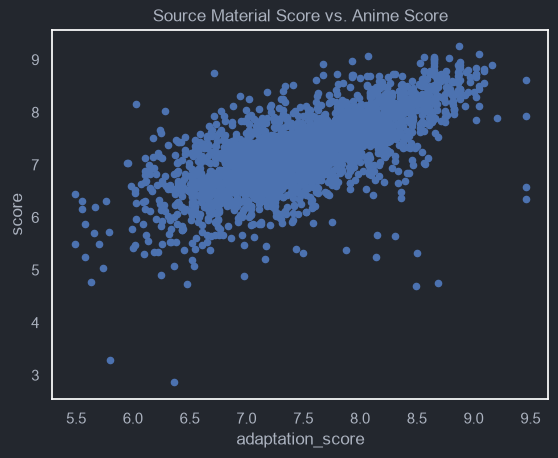

In [4]:
adaptation_df = df[~df['adaptation_score'].isna()]
adaptation_df.plot.scatter(x='adaptation_score', y='score', title='Source Material Score vs. Anime Score')
plt.show()

We will now perform a Linear Regression:

Correct R^2 Score: 0.49607137793545797


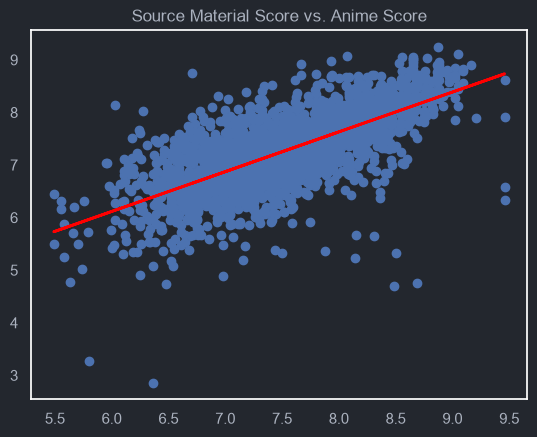

In [5]:
X = adaptation_df[['adaptation_score']]
y = adaptation_df[['score']]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)  
print(f"Correct R^2 Score: {r2}")

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title('Source Material Score vs. Anime Score')
plt.show()

We perform the same analysis on member count vs WC score:

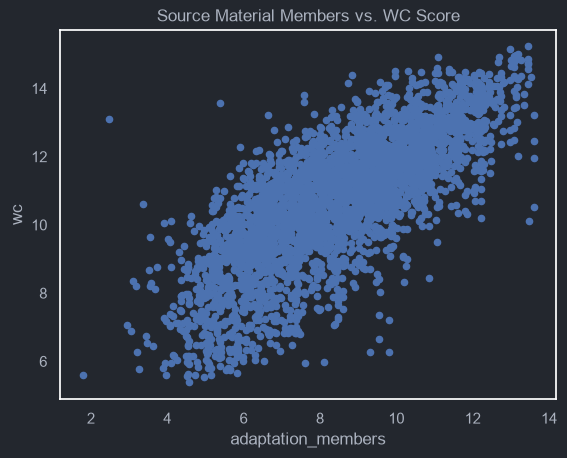

In [6]:
adaptation_df = df[~df['adaptation_members'].isna()]
adaptation_df.plot.scatter(x='adaptation_members', y='wc', title='Source Material Members vs. WC Score')
plt.show()

Correct R^2 Score: 0.5802566317398099


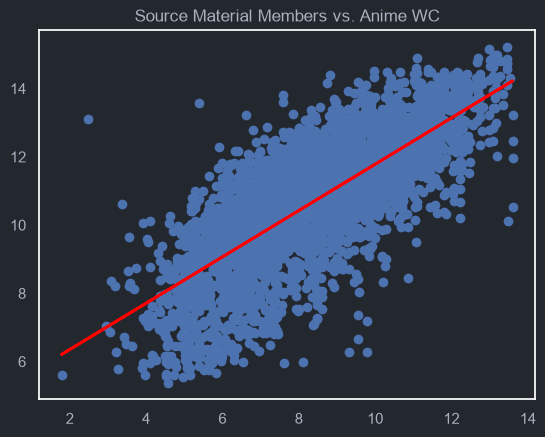

In [7]:
X = adaptation_df[['adaptation_members']]
y = adaptation_df[['wc']]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)  
print(f"Correct R^2 Score: {r2}")

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title('Source Material Members vs. Anime WC')
plt.show()

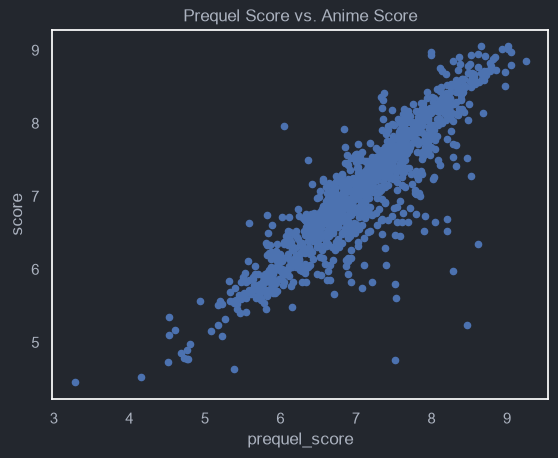

In [8]:
prequel_df = df[~df['prequel_score'].isna()]
prequel_df.plot.scatter(x='prequel_score', y='score', title='Prequel Score vs. Anime Score')
plt.show()

Correct R^2 Score: 0.8039592179553262


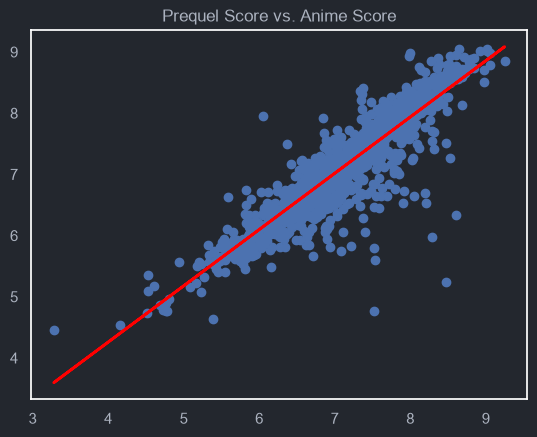

In [9]:
X = prequel_df[['prequel_score']]
y = prequel_df[['score']]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)  
print(f"Correct R^2 Score: {r2}")

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title('Prequel Score vs. Anime Score')
plt.show()

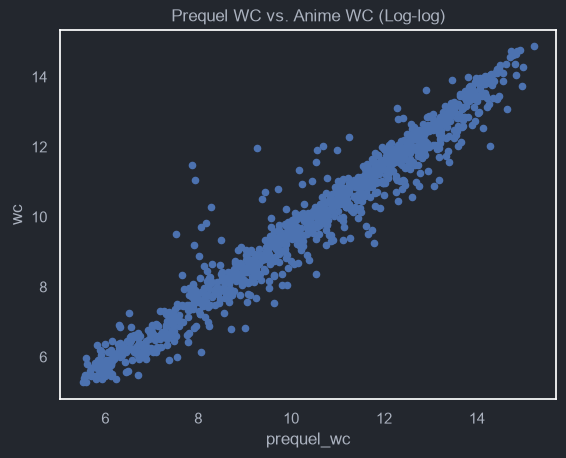

In [10]:
prequel_df = df[~df['prequel_wc'].isna()]
prequel_df.plot.scatter(x='prequel_wc', y='wc', title='Prequel WC vs. Anime WC (Log-log)')
plt.show()

Correct R^2 Score: 0.953611946584703


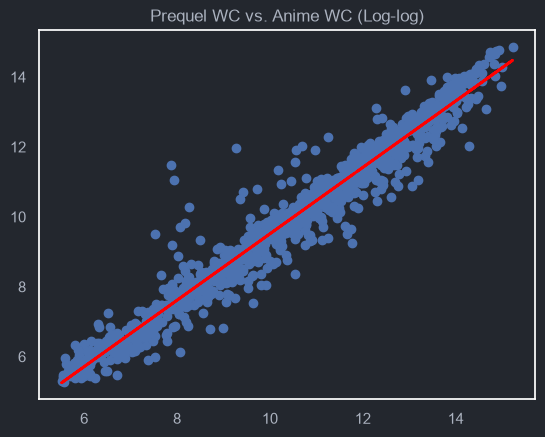

In [11]:
X = prequel_df[['prequel_wc']]
y = prequel_df[['wc']]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)  
print(f"Correct R^2 Score: {r2}")

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title('Prequel WC vs. Anime WC (Log-log)')
plt.show()

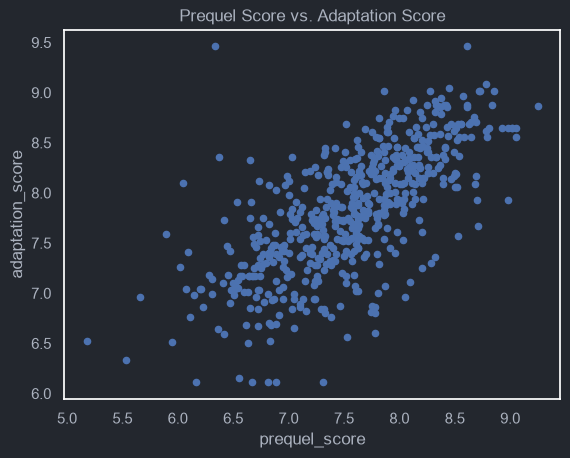

In [23]:
temp_df = df[~df['prequel_score'].isna() & ~df['adaptation_score'].isna()]
temp_df.plot.scatter(x='prequel_score', y='adaptation_score', title='Prequel Score vs. Adaptation Score')
plt.show()

Correct R^2 Score: 0.4979187027231313


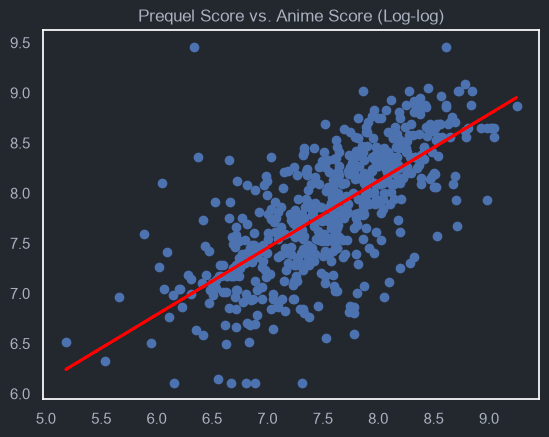

In [ ]:
X = temp_df[['prequel_score']]
y = temp_df[['adaptation_score']]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)  
print(f"Correct R^2 Score: {r2}")

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title('Prequel Score vs. Anime Score')
plt.show()

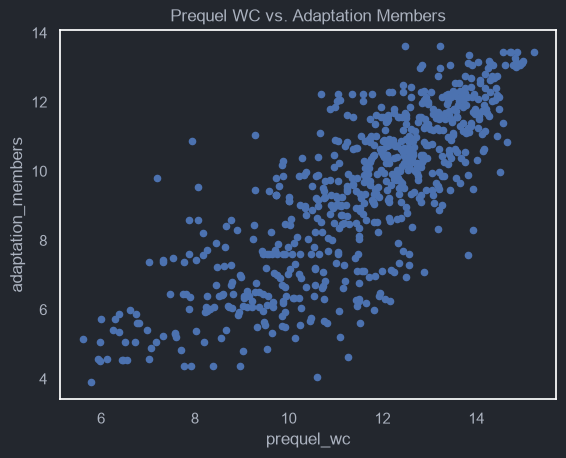

In [27]:
temp_df = df[~df['prequel_wc'].isna() & ~df['adaptation_members'].isna()]
temp_df.plot.scatter(x='prequel_wc', y='adaptation_members', title='Prequel WC vs. Adaptation Members')
plt.show()

Correct R^2 Score: 0.6396190303567898


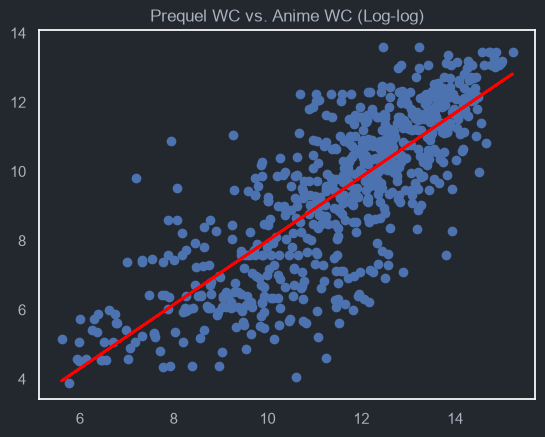

In [28]:
X = temp_df[['prequel_wc']]
y = temp_df[['adaptation_members']]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)  
print(f"Correct R^2 Score: {r2}")

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title('Prequel WC vs. Anime WC (Log-log)')
plt.show()

## Genre, Theme, Demographic vs. Score (Multiple Regression)

In [12]:
genre_averages = df.explode('genres').groupby('genres')['score'].mean().sort_values()
genre_counts = df['genres'].explode().value_counts()
print(genre_counts)
genre_averages

genres
Comedy           2124
Action           1463
Fantasy          1274
Adventure        1191
Sci-Fi            981
Romance           943
Drama             912
Supernatural      512
Mystery           375
Ecchi             331
Slice of Life     306
Sports            278
Suspense          187
Horror            157
Gourmet            77
Girls Love         46
Boys Love          37
Avant Garde        35
Erotica            11
Name: count, dtype: int64


genres
Erotica          6.118182
Ecchi            6.635287
Avant Garde      6.640857
Horror           6.697834
Comedy           6.777260
Sci-Fi           6.832181
Fantasy          6.865008
Adventure        6.901973
Gourmet          6.938701
Slice of Life    6.951732
Action           6.965393
Girls Love       6.999348
Boys Love        7.038919
Romance          7.073436
Supernatural     7.075664
Sports           7.077950
Mystery          7.146320
Drama            7.230110
Suspense         7.269412
Name: score, dtype: float64

In [13]:
distinct_genres = sorted({
    genre
    for genres in df['genres']
    for genre in genres
})

genre_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=distinct_genres,
    dtype=int
)

for idx, genres in df['genres'].items():
    if len(genres) > 0:  # handles [] naturally
        genre_matrix.loc[idx, genres] = 1


min_count = 50

genre_counts = genre_matrix.sum(axis=0)

valid_genres = genre_counts[
    genre_counts >= min_count
].index.tolist()

dropped = set(distinct_genres) - set(valid_genres)

if dropped:
    print(
        f"Dropping {len(dropped)} rare genres from regression: "
        f"{sorted(dropped)}"
    )

X = genre_matrix[valid_genres].copy()

X = sm.add_constant(X)

y = df['score']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

results = pd.DataFrame({
    'genre': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("genre != 'const'")


if not results.empty:
    results['pval_fdr'] = multipletests(
        results['pval'],
        method='fdr_bh'
    )[1]

    results['significant'] = results['pval_fdr'] < 0.05

else:
    results['pval_fdr'] = pd.Series(dtype=float)
    results['significant'] = pd.Series(dtype=bool)


results = results.sort_values('coef', ascending=False)

results

Dropping 4 rare genres from regression: ['Avant Garde', 'Boys Love', 'Erotica', 'Girls Love']
                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     41.87
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          6.00e-117
Time:                        18:43:51   Log-Likelihood:                -6034.2
No. Observations:                5310   AIC:                         1.210e+04
Df Residuals:                    5294   BIC:                         1.221e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

,genre,coef,pval,ci_low,ci_high,pval_fdr,significant
Sports,Sports,0.403618,4.005556e-16,0.306702,0.500535,1.502084e-15,True
Drama,Drama,0.392998,2.000217e-39,0.334835,0.451160,3.000326e-38,True
Suspense,Suspense,0.367713,1.400455e-09,0.248879,0.486546,2.334092e-09,True
Romance,Romance,0.304973,1.140622e-25,0.248188,0.361758,8.554668e-25,True
Slice of Life,Slice of Life,0.304298,5.150638e-10,0.208484,0.400113,9.657447e-10,True
Supernatural,Supernatural,0.246186,1.377490e-10,0.171141,0.321230,3.443725e-10,True
Mystery,Mystery,0.241422,2.383583e-08,0.156756,0.326088,3.575374e-08,True
Action,Action,0.213139,9.708583e-17,0.163013,0.263265,4.854291e-16,True
Gourmet,Gourmet,0.185538,3.372623e-02,0.014280,0.356796,4.215778e-02,True
Adventure,Adventure,0.080951,2.877143e-03,0.027732,0.134170,3.923377e-03,True


In [14]:
distinct_themes = sorted({
    theme
    for themes in df['themes']
    for theme in themes
})

theme_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=distinct_themes,
    dtype=int
)

for idx, themes in df['themes'].items():
    if len(themes) > 0:  # handles [] naturally
        theme_matrix.loc[idx, themes] = 1


min_count = 50

theme_counts = theme_matrix.sum(axis=0)

valid_themes = theme_counts[
    theme_counts >= min_count
].index.tolist()

dropped = set(distinct_themes) - set(valid_themes)

if dropped:
    print(
        f"Dropping {len(dropped)} rare themes from regression: "
        f"{sorted(dropped)}"
    )

X = theme_matrix[valid_themes].copy()

X = sm.add_constant(X)

y = df['score']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

results = pd.DataFrame({
    'theme': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("theme != 'const'")


if not results.empty:
    results['pval_fdr'] = multipletests(
        results['pval'],
        method='fdr_bh'
    )[1]

    results['significant'] = results['pval_fdr'] < 0.05

else:
    results['pval_fdr'] = pd.Series(dtype=float)
    results['significant'] = pd.Series(dtype=bool)


results = results.sort_values('coef', ascending=False)

results

Dropping 16 rare themes from regression: ['Childcare', 'Combat Sports', 'Crossdressing', 'Delinquents', 'Educational', 'High Stakes Game', 'Idols (Male)', 'Love Status Quo', 'Magical Sex Shift', 'Medical', 'Reverse Harem', 'Showbiz', 'Survival', 'Video Game', 'Villainess', 'Visual Arts']
                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     20.54
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          8.67e-123
Time:                        18:43:55   Log-Likelihood:                -5983.5
No. Observations:                5310   AIC:                         1.204e+04
Df Residuals:                    5273   BIC:                         1.228e+04
Df Model:                          36                                         


,theme,coef,pval,ci_low,ci_high,pval_fdr,significant
Iyashikei,Iyashikei,0.737894,6.926702e-18,0.570600,0.905187,8.312042e-17,True
Love Polygon,Love Polygon,0.499665,4.152515e-08,0.321316,0.678013,2.162380e-07,True
Organized Crime,Organized Crime,0.494997,3.482882e-06,0.286086,0.703909,1.139852e-05,True
Adult Cast,Adult Cast,0.488048,1.578683e-25,0.396906,0.579190,5.683259e-24,True
Gag Humor,Gag Humor,0.427708,1.891041e-10,0.296336,0.559080,1.701937e-09,True
Urban Fantasy,Urban Fantasy,0.373412,1.857236e-07,0.233176,0.513649,8.357562e-07,True
Otaku Culture,Otaku Culture,0.364619,1.690477e-04,0.174713,0.554526,4.346941e-04,True
Performing Arts,Performing Arts,0.362528,2.638090e-04,0.167865,0.557192,6.331415e-04,True
Psychological,Psychological,0.312837,6.194576e-07,0.189962,0.435712,2.230047e-06,True
Team Sports,Team Sports,0.305663,1.397732e-05,0.167856,0.443469,3.870641e-05,True


In [15]:
distinct_demos = sorted({
    demo
    for demos in df['demographics']
    for demo in demos
})

demo_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=distinct_demos,
    dtype=int
)

for idx, demos in df['demographics'].items():
    if len(demos) > 0:  # handles [] naturally
        demo_matrix.loc[idx, demos] = 1

X = demo_matrix.copy()

X = sm.add_constant(X)

y = df['score']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

results = pd.DataFrame({
    'demographic': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("demographic != 'const'")


if not results.empty:
    results['pval_fdr'] = multipletests(
        results['pval'],
        method='fdr_bh'
    )[1]

    results['significant'] = results['pval_fdr'] < 0.05

else:
    results['pval_fdr'] = pd.Series(dtype=float)
    results['significant'] = pd.Series(dtype=bool)


results = results.sort_values('coef', ascending=False)

results

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     152.6
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          6.62e-152
Time:                        18:43:58   Log-Likelihood:                -5974.9
No. Observations:                5310   AIC:                         1.196e+04
Df Residuals:                    5304   BIC:                         1.200e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7441      0.013    513.844      0.0

,demographic,coef,pval,ci_low,ci_high,pval_fdr,significant
Shounen,Shounen,0.561085,2.882999e-85,0.505888,0.616283,1.441499e-84,True
Shoujo,Shoujo,0.497562,1.826934e-21,0.395483,0.599640,2.283668e-21,True
Seinen,Seinen,0.440898,4.456049e-34,0.370378,0.511418,1.114012e-33,True
Josei,Josei,0.310149,2.875299e-04,0.142591,0.477708,2.875299e-04,True
Kids,Kids,-0.429817,1.326511e-27,-0.506777,-0.352858,2.210852e-27,True


## Genre, Theme, Demographic vs. WC (Multiple Regression)

In [16]:
distinct_genres = sorted({
    genre
    for genres in df['genres']
    for genre in genres
})

genre_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=distinct_genres,
    dtype=int
)

for idx, genres in df['genres'].items():
    if len(genres) > 0:  # handles [] naturally
        genre_matrix.loc[idx, genres] = 1


min_count = 50

genre_counts = genre_matrix.sum(axis=0)

valid_genres = genre_counts[
    genre_counts >= min_count
].index.tolist()

dropped = set(distinct_genres) - set(valid_genres)

if dropped:
    print(
        f"Dropping {len(dropped)} rare genres from regression: "
        f"{sorted(dropped)}"
    )

X = genre_matrix[valid_genres].copy()

X = sm.add_constant(X)

y = df['wc']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

results = pd.DataFrame({
    'genre': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("genre != 'const'")


if not results.empty:
    results['pval_fdr'] = multipletests(
        results['pval'],
        method='fdr_bh'
    )[1]

    results['significant'] = results['pval_fdr'] < 0.05

else:
    results['pval_fdr'] = pd.Series(dtype=float)
    results['significant'] = pd.Series(dtype=bool)


results = results.sort_values('coef', ascending=False)

results

Dropping 4 rare genres from regression: ['Avant Garde', 'Boys Love', 'Erotica', 'Girls Love']
                            OLS Regression Results                            
Dep. Variable:                     wc   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.246
Method:                 Least Squares   F-statistic:                     116.7
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:44:04   Log-Likelihood:                -11119.
No. Observations:                5310   AIC:                         2.227e+04
Df Residuals:                    5294   BIC:                         2.238e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

,genre,coef,pval,ci_low,ci_high,pval_fdr,significant
Suspense,Suspense,2.045408,8.646890e-38,1.735793,2.355024,3.242584e-37,True
Romance,Romance,1.583850,5.324862e-94,1.435900,1.731801,7.987293e-93,True
Action,Action,1.287737,1.693296e-80,1.157136,1.418337,1.269972e-79,True
Supernatural,Supernatural,1.014648,4.343581e-24,0.819123,1.210174,1.303074e-23,True
Fantasy,Fantasy,0.985024,3.388455e-42,0.844408,1.125640,1.694227e-41,True
Ecchi,Ecchi,0.923306,2.902869e-15,0.694725,1.151887,6.220433e-15,True
Gourmet,Gourmet,0.821212,3.113985e-04,0.375007,1.267417,3.892481e-04,True
Sports,Sports,0.777307,1.700626e-09,0.524795,1.029820,2.834377e-09,True
Drama,Drama,0.643947,1.015688e-16,0.492406,0.795487,2.539221e-16,True
Mystery,Mystery,0.619441,3.866182e-08,0.398848,0.840034,5.799274e-08,True


In [17]:
distinct_themes = sorted({
    theme
    for themes in df['themes']
    for theme in themes
})

theme_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=distinct_themes,
    dtype=int
)

for idx, themes in df['themes'].items():
    if len(themes) > 0:  # handles [] naturally
        theme_matrix.loc[idx, themes] = 1


min_count = 50

theme_counts = theme_matrix.sum(axis=0)

valid_themes = theme_counts[
    theme_counts >= min_count
].index.tolist()

dropped = set(distinct_themes) - set(valid_themes)

if dropped:
    print(
        f"Dropping {len(dropped)} rare themes from regression: "
        f"{sorted(dropped)}"
    )

X = theme_matrix[valid_themes].copy()

X = sm.add_constant(X)

y = df['wc']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

results = pd.DataFrame({
    'theme': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("theme != 'const'")


if not results.empty:
    results['pval_fdr'] = multipletests(
        results['pval'],
        method='fdr_bh'
    )[1]

    results['significant'] = results['pval_fdr'] < 0.05

else:
    results['pval_fdr'] = pd.Series(dtype=float)
    results['significant'] = pd.Series(dtype=bool)


results = results.sort_values('coef', ascending=False)

results

Dropping 16 rare themes from regression: ['Childcare', 'Combat Sports', 'Crossdressing', 'Delinquents', 'Educational', 'High Stakes Game', 'Idols (Male)', 'Love Status Quo', 'Magical Sex Shift', 'Medical', 'Reverse Harem', 'Showbiz', 'Survival', 'Video Game', 'Villainess', 'Visual Arts']
                            OLS Regression Results                            
Dep. Variable:                     wc   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     54.32
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:44:09   Log-Likelihood:                -11040.
No. Observations:                5310   AIC:                         2.215e+04
Df Residuals:                    5273   BIC:                         2.240e+04
Df Model:                          36                                         


,theme,coef,pval,ci_low,ci_high,pval_fdr,significant
Gore,Gore,1.968682,7.542815e-23,1.578296,2.359068,5.430827e-22,True
Love Polygon,Love Polygon,1.823457,1.239503e-14,1.361252,2.285663,4.958012e-14,True
Isekai,Isekai,1.784981,1.703133e-37,1.513668,2.056294,3.065639e-36,True
Urban Fantasy,Urban Fantasy,1.718641,2.639023e-20,1.355206,2.082075,1.357212e-19,True
Psychological,Psychological,1.562880,9.774903e-22,1.244439,1.881321,5.864942e-21,True
Otaku Culture,Otaku Culture,1.519918,1.507931e-09,1.027759,2.012077,4.935046e-09,True
Harem,Harem,1.378840,1.784157e-27,1.131342,1.626338,2.140988e-26,True
Organized Crime,Organized Crime,1.360770,8.594183e-07,0.819359,1.902181,2.062604e-06,True
School,School,1.315852,5.640671e-70,1.172137,1.459566,2.030642e-68,True
Adult Cast,Adult Cast,1.228319,3.504341e-24,0.992117,1.464521,3.153907e-23,True


In [18]:
distinct_demos = sorted({
    demo
    for demos in df['demographics']
    for demo in demos
})

demo_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=distinct_demos,
    dtype=int
)

for idx, demos in df['demographics'].items():
    if len(demos) > 0:  # handles [] naturally
        demo_matrix.loc[idx, demos] = 1

X = demo_matrix.copy()

X = sm.add_constant(X)

y = df['wc']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

results = pd.DataFrame({
    'demographic': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("demographic != 'const'")


if not results.empty:
    results['pval_fdr'] = multipletests(
        results['pval'],
        method='fdr_bh'
    )[1]

    results['significant'] = results['pval_fdr'] < 0.05

else:
    results['pval_fdr'] = pd.Series(dtype=float)
    results['significant'] = pd.Series(dtype=bool)


results = results.sort_values('coef', ascending=False)

results

                            OLS Regression Results                            
Dep. Variable:                     wc   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     217.8
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          5.81e-212
Time:                        18:44:12   Log-Likelihood:                -11382.
No. Observations:                5310   AIC:                         2.278e+04
Df Residuals:                    5304   BIC:                         2.281e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.6345      0.036    265.171      0.0

,demographic,coef,pval,ci_low,ci_high,pval_fdr,significant
Shounen,Shounen,1.211440,2.642695e-53,1.058637,1.364242,6.606736e-53,True
Seinen,Seinen,0.966729,4.256268e-22,0.771508,1.161949,7.093779e-22,True
Josei,Josei,0.900750,1.423022e-04,0.436899,1.364602,1.778777e-04,True
Shoujo,Shoujo,0.479890,8.768528e-04,0.197306,0.762474,8.768528e-04,True
Kids,Kids,-2.662539,1.133159e-125,-2.875586,-2.449492,5.665796e-125,True


## Genre, Theme, and Demographic vs. Drop Rate (Multiple Regression)

In [19]:
distinct_genres = sorted({
    genre
    for genres in df['genres']
    for genre in genres
})

genre_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=distinct_genres,
    dtype=int
)

for idx, genres in df['genres'].items():
    if len(genres) > 0:  # handles [] naturally
        genre_matrix.loc[idx, genres] = 1


min_count = 50

genre_counts = genre_matrix.sum(axis=0)

valid_genres = genre_counts[
    genre_counts >= min_count
].index.tolist()

dropped = set(distinct_genres) - set(valid_genres)

if dropped:
    print(
        f"Dropping {len(dropped)} rare genres from regression: "
        f"{sorted(dropped)}"
    )

X = genre_matrix[valid_genres].copy()

X = sm.add_constant(X)

y = df['drop_rate']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

results = pd.DataFrame({
    'genre': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("genre != 'const'")


if not results.empty:
    results['pval_fdr'] = multipletests(
        results['pval'],
        method='fdr_bh'
    )[1]

    results['significant'] = results['pval_fdr'] < 0.05

else:
    results['pval_fdr'] = pd.Series(dtype=float)
    results['significant'] = pd.Series(dtype=bool)


results = results.sort_values('coef', ascending=False)

results

Dropping 4 rare genres from regression: ['Avant Garde', 'Boys Love', 'Erotica', 'Girls Love']
                            OLS Regression Results                            
Dep. Variable:              drop_rate   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     42.74
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          1.97e-119
Time:                        18:44:19   Log-Likelihood:                 3287.3
No. Observations:                5310   AIC:                            -6543.
Df Residuals:                    5294   BIC:                            -6437.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

,genre,coef,pval,ci_low,ci_high,pval_fdr,significant
Sci-Fi,Sci-Fi,-0.005387,2.697969e-01,-0.014957,0.004182,2.890681e-01,False
Comedy,Comedy,-0.005924,1.653277e-01,-0.014294,0.002446,1.907628e-01,False
Adventure,Adventure,-0.006954,1.383488e-01,-0.016152,0.002244,1.729360e-01,False
Horror,Horror,-0.009842,3.860229e-01,-0.032097,0.012414,3.860229e-01,False
Mystery,Mystery,-0.022096,3.086577e-03,-0.036728,-0.007463,4.629866e-03,True
Fantasy,Fantasy,-0.023284,1.018647e-06,-0.032611,-0.013956,1.909963e-06,True
Supernatural,Supernatural,-0.039289,3.057272e-09,-0.052258,-0.026319,9.171816e-09,True
Gourmet,Gourmet,-0.039453,8.995248e-03,-0.069051,-0.009856,1.226625e-02,True
Ecchi,Ecchi,-0.042648,3.669442e-08,-0.057811,-0.027486,9.173606e-08,True
Suspense,Suspense,-0.043277,3.667733e-05,-0.063814,-0.022739,6.112888e-05,True


In [20]:
distinct_themes = sorted({
    theme
    for themes in df['themes']
    for theme in themes
})

theme_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=distinct_themes,
    dtype=int
)

for idx, themes in df['themes'].items():
    if len(themes) > 0:  # handles [] naturally
        theme_matrix.loc[idx, themes] = 1


min_count = 50

theme_counts = theme_matrix.sum(axis=0)

valid_themes = theme_counts[
    theme_counts >= min_count
].index.tolist()

dropped = set(distinct_themes) - set(valid_themes)

if dropped:
    print(
        f"Dropping {len(dropped)} rare themes from regression: "
        f"{sorted(dropped)}"
    )

X = theme_matrix[valid_themes].copy()

X = sm.add_constant(X)

y = df['drop_rate']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

results = pd.DataFrame({
    'theme': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("theme != 'const'")


if not results.empty:
    results['pval_fdr'] = multipletests(
        results['pval'],
        method='fdr_bh'
    )[1]

    results['significant'] = results['pval_fdr'] < 0.05

else:
    results['pval_fdr'] = pd.Series(dtype=float)
    results['significant'] = pd.Series(dtype=bool)


results = results.sort_values('coef', ascending=False)

results

Dropping 16 rare themes from regression: ['Childcare', 'Combat Sports', 'Crossdressing', 'Delinquents', 'Educational', 'High Stakes Game', 'Idols (Male)', 'Love Status Quo', 'Magical Sex Shift', 'Medical', 'Reverse Harem', 'Showbiz', 'Survival', 'Video Game', 'Villainess', 'Visual Arts']
                            OLS Regression Results                            
Dep. Variable:              drop_rate   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     19.42
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          1.78e-115
Time:                        18:44:25   Log-Likelihood:                 3314.4
No. Observations:                5310   AIC:                            -6555.
Df Residuals:                    5273   BIC:                            -6311.
Df Model:                          36                                         


,theme,coef,pval,ci_low,ci_high,pval_fdr,significant
Pets,Pets,0.048118,5.775918e-03,0.013957,0.082279,1.094384e-02,True
Parody,Parody,0.029180,2.507664e-03,0.010262,0.048097,6.018393e-03,True
Anthropomorphic,Anthropomorphic,0.029011,7.210084e-03,0.007853,0.050170,1.297815e-02,True
Music,Music,0.023002,3.381287e-02,0.001760,0.044243,4.867184e-02,True
Workplace,Workplace,0.015760,2.123294e-01,-0.009010,0.040530,2.635813e-01,False
Strategy Game,Strategy Game,0.008933,3.853709e-01,-0.011240,0.029106,4.335423e-01,False
Samurai,Samurai,0.007496,6.200488e-01,-0.022141,0.037132,6.734498e-01,False
Racing,Racing,0.006265,6.833901e-01,-0.023846,0.036375,7.029155e-01,False
Detective,Detective,0.003293,8.283296e-01,-0.026478,0.033065,8.283296e-01,False
Mecha,Mecha,-0.003404,6.360360e-01,-0.017507,0.010698,6.734498e-01,False


In [21]:
distinct_demos = sorted({
    demo
    for demos in df['demographics']
    for demo in demos
})

demo_matrix = pd.DataFrame(
    0,
    index=df.index,
    columns=distinct_demos,
    dtype=int
)

for idx, demos in df['demographics'].items():
    if len(demos) > 0:  # handles [] naturally
        demo_matrix.loc[idx, demos] = 1

X = demo_matrix.copy()

X = sm.add_constant(X)

y = df['drop_rate']

model = sm.OLS(y, X, missing='drop').fit()

print(model.summary())

results = pd.DataFrame({
    'demographic': model.params.index,
    'coef': model.params.values,
    'pval': model.pvalues.values,
    'ci_low': model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).query("demographic != 'const'")


if not results.empty:
    results['pval_fdr'] = multipletests(
        results['pval'],
        method='fdr_bh'
    )[1]

    results['significant'] = results['pval_fdr'] < 0.05

else:
    results['pval_fdr'] = pd.Series(dtype=float)
    results['significant'] = pd.Series(dtype=bool)


results = results.sort_values('coef', ascending=False)

results

                            OLS Regression Results                            
Dep. Variable:              drop_rate   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     135.0
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          4.04e-135
Time:                        18:44:28   Log-Likelihood:                 3301.9
No. Observations:                5310   AIC:                            -6592.
Df Residuals:                    5304   BIC:                            -6552.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1669      0.002     72.947      0.0

,demographic,coef,pval,ci_low,ci_high,pval_fdr,significant
Kids,Kids,0.131942,3.822020e-80,0.118529,0.145355,1.911010e-79,True
Shoujo,Shoujo,-0.041415,5.142971e-06,-0.059206,-0.023624,6.428713e-06,True
Seinen,Seinen,-0.045525,4.383705e-13,-0.057816,-0.033235,7.306175e-13,True
Josei,Josei,-0.047752,1.355990e-03,-0.076955,-0.018548,1.355990e-03,True
Shounen,Shounen,-0.058790,1.186531e-32,-0.068410,-0.049169,2.966328e-32,True
